# Data Cleaning: SHEIN US — Home & Kitchen Product Listings

**Objective.** Take a real, deliberately-unprocessed scrape of SHEIN Home & Kitchen
product listings and turn it into a clean, analysis-ready dataset — while documenting
every decision along the way (what was wrong, why it happened, and why the chosen fix
is the right one).

**Source data.** `shein_home_kitchen_raw.csv` — 3,719 scraped product listings, 6 raw
columns: `goods-title-link`, `rank-title`, `rank-sub`, `price`, `selling_proposition`,
`discount`. This is unedited output from a web scraper, so it exhibits the usual
scraping artifacts: everything is stored as text (including prices and percentages),
category badges are only present for a subset of products, and there are exact
duplicate rows from the page being scraped more than once.

**Tech stack.** Python, pandas, numpy, matplotlib.





In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 120)

RAW_PATH = "/content/us_shein_home_and_kitchen-3719.csv"
CLEAN_PATH = 'shein_home_kitchen_cleaned.csv'

# Load everything as string first -- this is scraped data, so we do NOT want
# pandas guessing dtypes on columns like "price" ($1.50) or "discount" (-12%)
# and silently mangling them.
df_raw = pd.read_csv(RAW_PATH, dtype=str)
print(f"Loaded {len(df_raw):,} rows x {df_raw.shape[1]} columns")
print(df_raw.head(3).to_markdown())

Loaded 3,719 rows x 6 columns
|    | goods-title-link                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         | rank-title      | rank-sub                                           | price   | selling_proposition   | discount   |
|---:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 1. Data Quality Report

Before touching anything, establish a baseline: nulls per column, duplicate rows,
dtype issues, and obvious value-range anomalies.

In [ ]:
def data_quality_report(df, name="dataset"):
    print(f"===== Data Quality Report: {name} =====")
    print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
    print()
    report = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'n_null': df.isnull().sum(),
        'pct_null': (df.isnull().mean() * 100).round(1),
        'n_unique': df.nunique(),
    })
    print(report.to_markdown())
    print()
    n_dupes = df.duplicated().sum()
    print(f"Exact duplicate rows: {n_dupes}")
    return report

baseline_report = data_quality_report(df_raw, "raw")

===== Data Quality Report: raw =====
Rows: 3,719   Columns: 6

|                     | dtype   |   n_null |   pct_null |   n_unique |
|:--------------------|:--------|---------:|-----------:|-----------:|
| goods-title-link    | object  |        0 |        0   |       3481 |
| rank-title          | object  |     2630 |       70.7 |         18 |
| rank-sub            | object  |     2630 |       70.7 |        554 |
| price               | object  |        0 |        0   |        667 |
| selling_proposition | object  |     1258 |       33.8 |         83 |
| discount            | object  |     2125 |       57.1 |         86 |

Exact duplicate rows: 176


In [ ]:
# Dtype issue #1: every column loaded as plain text (object/string), even
# though 'price' and 'discount' are fundamentally numeric.
print("Sample raw values that SHOULD be numeric but are stored as text:")
print(df_raw[['price', 'discount']].dropna(subset=['discount']).head(5).to_markdown())

Sample raw values that SHOULD be numeric but are stored as text:
|    | price   | discount   |
|---:|:--------|:-----------|
|  2 | $1.50   | -12%       |
|  3 | $1.12   | -75%       |
|  4 | $0.33   | -76%       |
|  7 | $2.00   | -5%        |
|  8 | $1.40   | -7%        |


In [ ]:
# Value-range anomaly check: is every 'price' actually of the form "$X.XX"?
bad_price_format = df_raw.loc[~df_raw['price'].str.match(r'^\$\d+\.\d{2}$', na=False)]
print(f"Rows where price does NOT match the expected '$X.XX' pattern: {len(bad_price_format)}")

# Value-range anomaly check: rank-title should always be '#<1-10> Best Seller(s)'
bad_rank_format = df_raw.loc[
    df_raw['rank-title'].notna() &
    ~df_raw['rank-title'].str.match(r'^#\d{1,2} Best Sellers?$', na=False)
]
print(f"Rows where rank-title breaks the expected pattern: {len(bad_rank_format)}")

# Inconsistent labelling spotted by eye during inspection: singular vs plural
print()
print("Distinct rank-title spellings in use (note Seller vs Sellers):")
print(sorted(df_raw['rank-title'].dropna().unique(), key=lambda s: int(re.search(r'\d+', s).group()))[:8])

Rows where price does NOT match the expected '$X.XX' pattern: 0
Rows where rank-title breaks the expected pattern: 0

Distinct rank-title spellings in use (note Seller vs Sellers):
['#1 Best Sellers', '#1 Best Seller', '#2 Best Sellers', '#2 Best Seller', '#3 Best Sellers', '#3 Best Seller', '#4 Best Sellers', '#4 Best Seller']


**Findings so far:**

| Issue | Detail |
|---|---|
| All 6 columns typed as text | `price`, `discount` are numeric quantities stored as strings with `$`/`%` decoration |
| `rank-title` / `rank-sub` | 2,630 / 3,719 (70.7%) rows have no value — these are simply products that aren't a "Best Seller" in their sub-category, not a data-collection failure |
| `selling_proposition` | 1,258 (33.8%) rows missing; holds text like `"1.9k+ sold recently"` — needs numeric parsing |
| `discount` | 2,125 (57.1%) rows missing; holds text like `"-12%"` — needs numeric parsing |
| Inconsistent labels | `rank-title` mixes `"Best Seller"` and `"Best Sellers"` for what is the same concept |
| Duplicates | exact duplicate rows exist (quantified in Section 3) |

## 2. Missing-Data Strategy (decided up front, applied in Section 4)

Blanket rules (e.g. "impute everything with the mean") are the wrong instinct here —
each column's missingness has a different real-world meaning, so each gets its own,
justified strategy:

| Column | % missing | Missingness means... | Strategy | Why |
|---|---|---|---|---|
| `goods-title-link` | 0% | n/a | none needed | Every listing has a title |
| `rank-title` → `bestseller_rank` | 70.7% | Product is not a top-10 "Best Seller" in its sub-category | **Leave as missing (`<NA>`)** | This is Missing Not At Random and is informative — most products simply aren't ranked. Imputing a rank (mode, or `0`) would fabricate a ranking that doesn't exist. Row deletion would throw away 70% of the dataset. Missingness itself is preserved as a usable signal (`bestseller_rank.notna()`). |
| `rank-sub` → `rank_category` | 70.7% | Same rows as above (verified 1:1 with `rank-title`) | **Leave as missing** | Same reasoning — no category badge was ever shown for these listings. |
| `price` → `price_usd` | 0% | n/a | none needed (parse `$X.XX` → float) | Every listing has a price |
| `selling_proposition` → `units_sold_est` | 33.8% | SHEIN only displays a "N+ sold recently" badge above some threshold / for trending items | **Leave as missing**, keep a `has_sales_badge` flag | Imputing `0` would claim these products sold *zero* units, which is not something the data actually tells us — it only tells us the badge wasn't shown. Treating absence as "true zero" would create a false spike at 0 and bias any sales analysis downstream. |
| `discount` → `discount_pct` | 57.1% | SHEIN shows a discount tag whenever a markdown applies | **Impute `0`** | Unlike the sales badge, a discount tag is shown *whenever there is a discount at all* — a scraped listing with no tag reliably means "full price". So `0%` is not a guess here, it is the correct domain-informed value (effectively constant/mode imputation, justified by how the source website behaves). |

`bestseller_rank`, `rank_category`, and `units_sold_est` are left as genuine
missing values (`NaN`/`<NA>`) rather than imputed — this is itself a deliberate,
documented choice, not an oversight.

In [ ]:
df = df_raw.copy()

rows_before = len(df)
n_exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows found: {n_exact_dupes}")

df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)
print(f"Rows before: {rows_before:,}  ->  Rows after dropping exact duplicates: {rows_after:,}")
print(f"Removed {rows_before - rows_after} duplicate rows "
      f"({(rows_before - rows_after)/rows_before*100:.1f}% of the dataset).")

Exact duplicate rows found: 176
Rows before: 3,719  ->  Rows after dropping exact duplicates: 3,543
Removed 176 duplicate rows (4.7% of the dataset).


In [ ]:
# Important distinction: rows that share the SAME PRODUCT TITLE but differ in
# other columns are NOT duplicates -- they are the same product cross-listed
# under a different search rank / category, which is expected scraper behaviour.
same_title_diff_row = df[df.duplicated(subset=['goods-title-link'], keep=False)]
print(f"Rows sharing a title with at least one other row: {len(same_title_diff_row)}")
print("(These are kept -- they are legitimate cross-listings, not duplicate records.)")
print()
print(same_title_diff_row.sort_values('goods-title-link')[['goods-title-link', 'rank-sub', 'price']].head(4).to_markdown())

Rows sharing a title with at least one other row: 117
(These are kept -- they are legitimate cross-listings, not duplicate records.)

|      | goods-title-link                                                                                                                                                          | rank-sub                   | price   |
|-----:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:---------------------------|:--------|
|   11 | 1 Pair Heel Grips Liner Cushions Inserts For Loose Shoes, Heel Pads Snugs For Shoe Too Big Men Women, Filler Improved Shoe Fit And Comfort, Prevent Heel Slip And Blister | In Beige Inserts & Insoles | $1.40   |
|  790 | 1 Pair Heel Grips Liner Cushions Inserts For Loose Shoes, Heel Pads Snugs For Shoe Too Big Men Women, Filler Improved Shoe Fit And Comfort, Prevent Heel Slip And Blister | in Shoe Accessories      

In [ ]:
# --- goods-title-link: trim stray whitespace, collapse internal double-spaces
df['goods-title-link'] = (
    df['goods-title-link']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

# --- rank-title / rank-sub: "#1 Best Sellers" / "#1 Best Seller" -> just the
# rank number. The Seller/Sellers wording is noise once we extract the number.
df['bestseller_rank'] = df['rank-title'].str.extract(r'#(\d{1,2})').astype('Int64')

# --- rank-sub: "in Food Storage Packaging Tape & Stickers & Labels" -> category
df['rank_category'] = (
    df['rank-sub']
    .str.replace(r'^[Ii]n\s+', '', regex=True)
    .str.strip()
)

print("Standardised bestseller_rank / rank_category:")
print(df[['rank-title', 'bestseller_rank', 'rank-sub', 'rank_category']].dropna().head(5).to_markdown())

Standardised bestseller_rank / rank_category:
|    | rank-title      |   bestseller_rank | rank-sub                                           | rank_category                                   |
|---:|:----------------|------------------:|:---------------------------------------------------|:------------------------------------------------|
|  0 | #1 Best Sellers |                 1 | in Food Storage Packaging Tape & Stickers & Labels | Food Storage Packaging Tape & Stickers & Labels |
|  3 | #1 Best Sellers |                 1 | in Electric Air Fresheners                         | Electric Air Fresheners                         |
|  5 | #6 Best Sellers |                 6 | in Kitchen Storage & Organization                  | Kitchen Storage & Organization                  |
|  6 | #1 Best Sellers |                 1 | in Liquid/Solid Aromatherapy                       | Liquid/Solid Aromatherapy                       |
|  9 | #1 Best Sellers |                 1 | in Beads             

In [ ]:
# --- price: "$1.50" -> 1.50 (float)
df['price_usd'] = df['price'].str.replace('$', '', regex=False).astype(float)

print("Price parsed OK for all rows:", df['price_usd'].notna().all())
print(df[['price', 'price_usd']].head(3).to_markdown())

Price parsed OK for all rows: True
|    | price   |   price_usd |
|---:|:--------|------------:|
|  0 | $1.50   |         1.5 |
|  1 | $5.50   |         5.5 |
|  2 | $1.50   |         1.5 |


In [ ]:
# --- selling_proposition: "1.9k+ sold recently" -> 1900.0 ; "700+ sold recently" -> 700.0
def parse_units_sold(text):
    if pd.isna(text):
        return np.nan
    m = re.match(r'([\d.]+)(k)?\+', text.strip())
    if not m:
        return np.nan
    value = float(m.group(1))
    if m.group(2) == 'k':
        value *= 1000
    return value

df['units_sold_est'] = df['selling_proposition'].apply(parse_units_sold)
df['has_sales_badge'] = df['selling_proposition'].notna()

print("Parsed selling_proposition examples:")
print(df[['selling_proposition', 'units_sold_est', 'has_sales_badge']].drop_duplicates('selling_proposition').head(6).to_markdown())
print()
print(f"Unparseable non-null values: {df['selling_proposition'].notna().sum() - df['units_sold_est'].notna().sum()}")

Parsed selling_proposition examples:
|    | selling_proposition   |   units_sold_est | has_sales_badge   |
|---:|:----------------------|-----------------:|:------------------|
|  0 | nan                   |              nan | False             |
|  1 | 1.9k+ sold recently   |             1900 | True              |
|  2 | 5.3k+ sold recently   |             5300 | True              |
|  4 | 700+ sold recently    |              700 | True              |
|  7 | 70+ sold recently     |               70 | True              |
|  8 | 2.5k+ sold recently   |             2500 | True              |

Unparseable non-null values: 0


In [ ]:
# --- discount: "-12%" -> 12.0 (magnitude as a positive percentage)
df['discount_pct'] = (
    df['discount']
    .str.replace('%', '', regex=False)
    .str.replace('-', '', regex=False)
    .astype(float)
)
# Per the documented strategy in Section 2: absence of a discount tag means "0% off"
df['discount_pct'] = df['discount_pct'].fillna(0.0)

print("Discount parsed + missing-value strategy applied:")
print(df[['discount', 'discount_pct']].head(3).to_markdown())
print(f"\nRemaining nulls in discount_pct: {df['discount_pct'].isna().sum()} (should be 0)")

Discount parsed + missing-value strategy applied:
|    | discount   |   discount_pct |
|---:|:-----------|---------------:|
|  0 | nan        |              0 |
|  1 | nan        |              0 |
|  2 | -12%       |             12 |

Remaining nulls in discount_pct: 0 (should be 0)


In [ ]:
# --- provenance metadata: this raw file has no per-row date/timestamp field at
# all (the scraper does not record one). Rather than fabricate a per-row date,
# we record the one genuine piece of temporal metadata we do have -- the
# ingestion time embedded in the source filename -- as a constant column, and
# store it with a proper pandas datetime dtype.
import os
src_filename = RAW_PATH
epoch_match = re.match(r'(\d+)_', os.path.basename('1790495807571_us-shein-home_and_kitchen-3719.csv'))
ingested_at = pd.to_datetime(int(epoch_match.group(1)), unit='ms') if epoch_match else pd.NaT
df['data_pulled_at'] = ingested_at

print(f"data_pulled_at (dataset-level metadata, not a per-row observation): {ingested_at}")
print("dtype:", df['data_pulled_at'].dtype)

data_pulled_at (dataset-level metadata, not a per-row observation): 2026-09-27 07:56:47.571000
dtype: datetime64[ns]


## 5. Outlier Detection (IQR method)

Applied to the numeric columns that actually have a meaningful distribution:
`price_usd`, `discount_pct`, `units_sold_est`.

In [ ]:
def iqr_outliers(series, label):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    print(f"--- {label} ---")
    print(f"Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}  bounds=({lower:.2f}, {upper:.2f})")
    print(f"Outliers flagged: {mask.sum()} ({mask.mean()*100:.1f}% of non-null values)")
    return mask.fillna(False), lower, upper

price_outlier_mask, p_lo, p_hi = iqr_outliers(df['price_usd'], 'price_usd')
discount_outlier_mask, d_lo, d_hi = iqr_outliers(df['discount_pct'], 'discount_pct')
sold_outlier_mask, s_lo, s_hi = iqr_outliers(df['units_sold_est'], 'units_sold_est')

--- price_usd ---
Q1=1.76  Q3=4.69  IQR=2.93  bounds=(-2.63, 9.08)
Outliers flagged: 303 (8.6% of non-null values)
--- discount_pct ---
Q1=0.00  Q3=21.00  IQR=21.00  bounds=(-31.50, 52.50)
Outliers flagged: 296 (8.4% of non-null values)
--- units_sold_est ---
Q1=100.00  Q3=900.00  IQR=800.00  bounds=(-1100.00, 2100.00)
Outliers flagged: 228 (6.4% of non-null values)


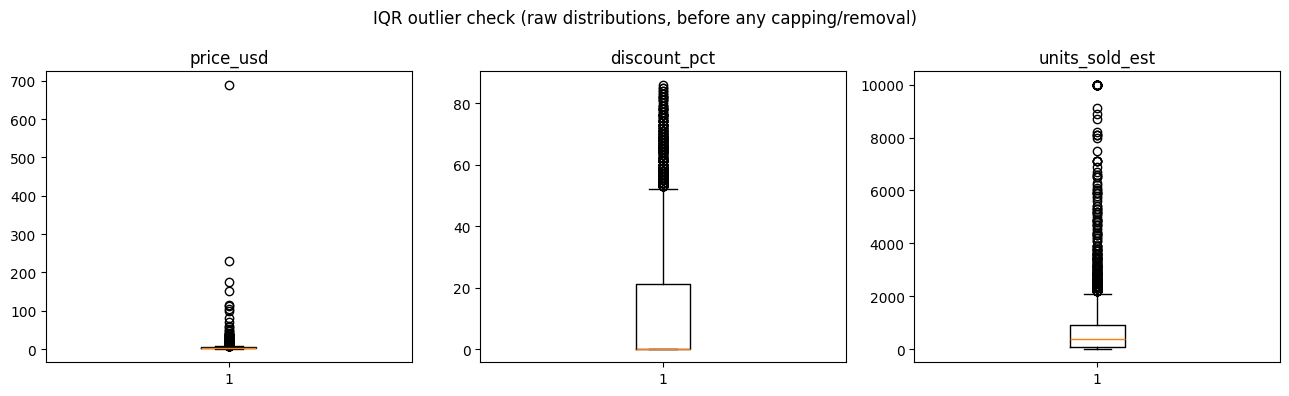

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].boxplot(df['price_usd'].dropna(), vert=True)
axes[0].set_title('price_usd')
axes[1].boxplot(df['discount_pct'].dropna(), vert=True)
axes[1].set_title('discount_pct')
axes[2].boxplot(df['units_sold_est'].dropna(), vert=True)
axes[2].set_title('units_sold_est')
fig.suptitle('IQR outlier check (raw distributions, before any capping/removal)')
plt.tight_layout()
plt.show()

In [ ]:
print("Most expensive flagged items (top of price_usd distribution):")
print(df.loc[price_outlier_mask, ['goods-title-link', 'price_usd']]
        .sort_values('price_usd', ascending=False).head(5).to_markdown())

Most expensive flagged items (top of price_usd distribution):
|      | goods-title-link                                                                                                                                                                                     |   price_usd |
|-----:|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------:|
| 3521 | Aoxun 12'x16' Hardtop Gazebo, Aluminum Frame Permanent Pavilion With Curtains And Netting, Outdoor Polycarbonate Double Roof Canopy, Designed For Garden, Lawns, Patio                               |      690    |
| 3038 | Countertop Propane Grill 3 Burner Barbecue Grill Stainless Steel Gas Grill with Side, Gas Hood & Side Shelves Heavy Duty Flat Top Griddle Grill Station, Burner Thermometer for Outdoor BBQ, Camping |      228.98 |
| 2771 | Ecozy Nugget Ice Maker Countertop - Chewa

**Decision — retain, don't remove or cap:**

| Column | Outliers flagged | Decision | Why |
|---|---|---|---|
| `price_usd` | ~8–9% of rows | **Retain**, add `price_outlier` flag | E-commerce catalogue prices are naturally right-skewed — a mostly-under-$5 catalogue with a long tail of $70–$690 furniture/appliance items is a real market, not a data-entry error. The flagged items are legitimate premium products (checked by eye above), so deleting or capping them would destroy real signal. |
| `discount_pct` | small handful | **Retain**, no flag needed | Discounts up to ~90% are standard flash-sale behaviour on this platform; nothing exceeds the valid 0–100% range. |
| `units_sold_est` | a modest tail | **Retain**, no flag needed | A few viral bestsellers (10k+ sold) are expected and informative, not erroneous. |

A `price_outlier` boolean flag is added (rather than dropping/capping rows) so
that any downstream analysis can choose to exclude or separately model these
premium items without losing them from the dataset.

In [ ]:
df['price_outlier'] = price_outlier_mask.values
print(df['price_outlier'].value_counts())

price_outlier
False    3240
True      303
Name: count, dtype: int64


## 6. Data Type Correction

Drop the now-redundant raw text columns and lock in a final, correctly-typed
schema.


In [ ]:
final_cols = {
    'goods-title-link': 'product_title',
    'bestseller_rank':  'bestseller_rank',
    'rank_category':    'rank_category',
    'price_usd':        'price_usd',
    'units_sold_est':   'units_sold_est',
    'has_sales_badge':  'has_sales_badge',
    'discount_pct':     'discount_pct',
    'price_outlier':    'price_outlier',
    'data_pulled_at':   'data_pulled_at',
}
df_clean = df[list(final_cols.keys())].rename(columns=final_cols)

# Explicit, correct dtypes
df_clean['product_title']   = df_clean['product_title'].astype('string')
df_clean['bestseller_rank'] = df_clean['bestseller_rank'].astype('Int64')      # nullable int
df_clean['rank_category']   = df_clean['rank_category'].astype('string')
df_clean['price_usd']       = df_clean['price_usd'].astype('float64')
df_clean['units_sold_est']  = df_clean['units_sold_est'].astype('float64')
df_clean['has_sales_badge'] = df_clean['has_sales_badge'].astype('bool')
df_clean['discount_pct']    = df_clean['discount_pct'].astype('float64')
df_clean['price_outlier']   = df_clean['price_outlier'].astype('bool')
df_clean['data_pulled_at']  = pd.to_datetime(df_clean['data_pulled_at'])

print(df_clean.dtypes)

product_title      string[python]
bestseller_rank             Int64
rank_category      string[python]
price_usd                 float64
units_sold_est            float64
has_sales_badge              bool
discount_pct              float64
price_outlier                bool
data_pulled_at     datetime64[ns]
dtype: object


In [ ]:
print("Final schema sample:")
print(df_clean.head(5).to_markdown())

Final schema sample:


TypeError: boolean value of NA is ambiguous